# Faster R-CNN Fracture Detection From X-Ray Images

## Summary

The objective of this notebook is to detect fractures using Faster R-CNN.

### Model

The model that we are using is the Faster R-CNN. This model specializes in object detection and has a reputation for being performant.

### Dataset

The FracAtlas dataset is public and free to use here: https://figshare.com/articles/dataset/The_dataset/22363012?file=43283628 <br>
Dataset will be stored in a directory alongside this notebook `./FracAtlas`.

## Set up dependencies

Configure dependencies ahead of time to keep organized and solve dependency issues ahead of time.

In [19]:
## Setting up dependencies

# Core utilities
import os
import sys
from collections import defaultdict

# Numerical computing & image processing
import numpy as np
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# PyTorch for deep learning
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
import torch.optim as optim

# Torchvision models & utilities
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign
from torchvision.datasets import CocoDetection
import torchvision.transforms as transforms

# Model evaluation & metrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchmetrics.detection.iou import IntersectionOverUnion
from sklearn.metrics import precision_score, recall_score

# Progress tracking
from tqdm import tqdm

## Creating the Faster R-CNN Model.
This model will be created using a pretrained Faster R-CNN on a ResNet-50 base.

We will narrow the model down to understand 2 classes of features; fracture and background.

In [21]:
# Load a pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

# Adjust the number of classes (background + object)
num_classes = 2  # background + fractures
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace the models default box predictor with one that has 2 output classes.
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

## Test the RPN

Loads a sample image from the dataset and demonstrate the out-of-the-box RPN (Region Proposal Network) output.

This will ensure the following:
- Instantiated correctly
- Can process an image
- Can propose features on an image within the dataset.

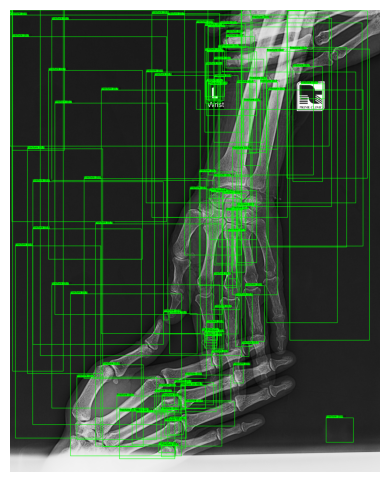

Saved output to: pre_trained_output_predictions.jpg


In [23]:
# Load sample image
image = Image.open("FracAtlas/images/Fractured/IMG0000019.jpg")
transform = transforms.Compose([transforms.ToTensor()])
image_tensor = transform(image).unsqueeze(0)

# Run inference
model.eval()
with torch.no_grad():
    predictions = model(image_tensor)

# Extract bounding boxes, labels, and scores
boxes = predictions[0]['boxes']
scores = predictions[0]['scores']
labels = predictions[0]['labels']

# Define label map
label_map = {1: "Fracture"}

# Convert PIL image to OpenCV format
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Set a threshold to filter only high-confidence predictions
threshold = 0.5
for i, box in enumerate(boxes):
    if scores[i] > threshold:
        x1, y1, x2, y2 = map(int, box.tolist())

        # Draw bounding box
        cv2.rectangle(image_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Get label text
        label_text = f"{label_map.get(labels[i].item(), 'Unknown')} ({scores[i]:.2f})"

        # Draw label background rectangle
        cv2.rectangle(image_cv, (x1, y1 - 15), (x1 + len(label_text) * 7, y1), (0, 255, 0), -1)

        # Overlay label text
        cv2.putText(image_cv, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 
                    0.5, (0, 0, 0), 1, cv2.LINE_AA)

# Convert back to RGB for plotting
image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

# Save the processed image
output_path = "pre_trained_output_predictions.jpg"
cv2.imwrite(output_path, cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR))

print(f"Saved output to: {output_path}")

## Chose the device

This will favor `cuda` to take advantage of the GPU if available and conifigured correctly; otherwise will settle for the `cpu`.

Moves model to the device.

In [25]:
# Automatically detect if GPU is available, otherwise fallback to CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Move model to the correct device
model.to(device)

Using device: cuda


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Initialize the Dataset

Initialize the dataset into memory.

Further processing will be required before it can be used.

In [27]:
# Define transformations
transform = transforms.Compose([transforms.ToTensor()])

# Load dataset (COCO format)
dataset = CocoDetection(root="FracAtlas/images/Fractured", annFile="FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json", transform=transform)

print(f"Size of dataset: {len(dataset)}")

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Size of dataset: 717


## Convert the dataset into a suitable one for Faster R-CNN

Dataset does not come with Faster R-CNN annotations. We need to convert annotations that are provided (COCO chosen) and make them work for Faster R-CNN.

In [29]:
# Define a custom dataset class that returns values suited for Faster R-CNN.
class ModifiedCocoDataset(Dataset):
    def __init__(self, base_dataset, modified_targets):
        self.base_dataset = base_dataset
        self.modified_targets = modified_targets
        
        assert len(base_dataset) == len(modified_targets), "Mismatch between dataset size and modified targets!"
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx] # Retrieve original image
        target = self.modified_targets[idx + 1]  # Retrieve modified targets

        # Convert COCO-style boxes (x, y, width, height) → Faster R-CNN format (x1, y1, x2, y2)
        boxes = torch.tensor([
            [bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]]  # (x1, y1, x2, y2)
            for bbox in target["boxes"]
        ], dtype=torch.float32)
        
        # Adjust labels (shift from 0-based to 1-based)
        labels = torch.tensor([label + 1 for label in target["labels"]], dtype=torch.int64)
        
        # Ensure targets are correctly structured for Faster R-CNN
        formatted_target = {"boxes": boxes, "labels": labels}

        return image, formatted_target

# Create the dataset
dataset = CocoDetection(root="FracAtlas/images/Fractured", annFile="FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json", transform=transform)

# Create a dictionary to group annotations by image_id
grouped_targets = defaultdict(lambda: {"boxes": [], "labels": []})

for idx in range(len(dataset)):  # Iterate through dataset entries
    _, target = dataset[idx]  # Unpack image and annotation data

    for obj in target:  # Iterate through objects within target
        image_id = obj["image_id"]        
        if image_id == 0:  # Skip this entirely
            continue  
        grouped_targets[image_id]["boxes"].append(obj["bbox"])
        grouped_targets[image_id]["labels"].append(obj["category_id"])

# Convert lists to tensors
for image_id in grouped_targets:
    grouped_targets[image_id]["boxes"] = torch.tensor(grouped_targets[image_id]["boxes"], dtype=torch.float32).to(device)
    grouped_targets[image_id]["labels"] = torch.tensor(grouped_targets[image_id]["labels"], dtype=torch.int64).to(device)

# Ensure there is no index 0.
grouped_targets = {k: v for k, v in grouped_targets.items() if k != 0}

# Ensure the new targets list is correctly structured
assert len(dataset) == len(grouped_targets), "Mismatch between dataset size and modified targets!"

# Wrap the original dataset with modified targets
modified_dataset = ModifiedCocoDataset(dataset, grouped_targets)

# Index 19 should have 1 bounding box, where index 20 should have 2. Assert this.
image_id_to_search = 19
image, targets = modified_dataset[image_id_to_search]
print(f"Sample {image_id_to_search} targets: {targets}")
image_id_to_search = 20
image, targets = modified_dataset[image_id_to_search]
print(f"Sample {image_id_to_search} targets: {targets}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Sample 19 targets: {'boxes': tensor([[1312.5719,  770.1890, 1458.5210,  858.1101],
        [ 470.2876,  750.8463,  596.8940,  842.2843]]), 'labels': tensor([1, 1])}
Sample 20 targets: {'boxes': tensor([[304.8488, 222.5127, 343.7732, 248.2580],
        [ 98.5801, 201.6713, 134.7461, 225.2712]]), 'labels': tensor([1, 1])}


## Split the data

The dataset comes out of the box with a roughly **80-10-10** **train-valid-test** split.

We will match that, while randomizing the chosen images.

In [31]:
# Define the split ratio (e.g., 80% train, 10% validation, 10% test)
print(f"Total images: {len(modified_dataset)}")

train_size = int(0.8 * len(modified_dataset))
val_size = int((len(modified_dataset) - train_size) / 2)
test_size = int(len(modified_dataset) - train_size - val_size)
print(f"Image split. Training: {train_size}. Validation: {val_size}. Test: {test_size}")

# Create split datasets
train_dataset, val_dataset, test_dataset = random_split(modified_dataset, [train_size, val_size, test_size])

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda batch: list(zip(*batch)))
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=True, collate_fn=lambda batch: list(zip(*batch)))
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=True, collate_fn=lambda batch: list(zip(*batch)))

print(f"Data batch split. Training: {len(train_loader)}. Validation: {len(val_loader)}. Test: {len(test_loader)}")

Total images: 717
Image split. Training: 573. Validation: 72. Test: 72
Data batch split. Training: 287. Validation: 36. Test: 36


## Test the DataLoader

This will ensure that the DataLoader is Faster R-CNN ready.

Demonstrate the following:
- Return values are in the expected format
- Image is loaded
- Annotations are applied to the image
- Bounding boxes line up correctly

Sample Target Type: <class 'dict'>
Sample Target: {'boxes': tensor([[ 750.4158,  976.6337, 1018.9307, 1202.3762]]), 'labels': tensor([1])}
tensor([[ 750.4158,  976.6337, 1018.9307, 1202.3762]])
tensor([1])
Bounding Box: (750, 976, 1018, 1202), Label: 1
Bounding Box values: (750, 976, 1018, 1202), Label: 1
Image Shape: (2880, 2304, 3)


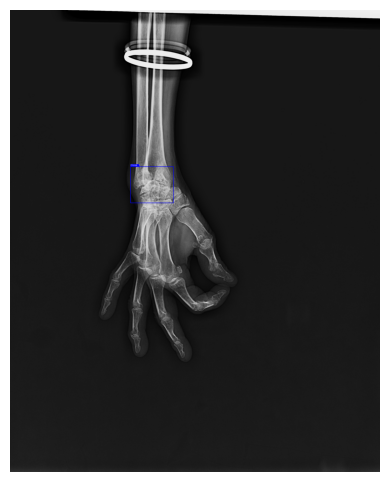

In [33]:
# Select a sample image from the dataset
sample_image, sample_target = modified_dataset[18]  # Get the first image & annotations

print("Sample Target Type:", type(sample_target))
print("Sample Target:", sample_target)

boxes = sample_target['boxes']
labels = sample_target['labels']

print(boxes)
print(labels)

# Move tensors to CPU and convert to lists for processing
boxes = boxes.cpu().tolist()
labels = labels.cpu().tolist()

# Extract bounding box coordinates
for box, label in zip(boxes, labels):
    x1, y1, x2, y2 = map(int, box)  # Extract raw bounding box coordinates

    print(f"Bounding Box: ({x1}, {y1}, {x2}, {y2}), Label: {label}")

# Convert tensor image to OpenCV-compatible format
image_np = sample_image.permute(1, 2, 0).cpu().numpy()  # Convert [C, H, W] -> [H, W, C]
image_np = (image_np * 255).astype(np.uint8)  # Scale pixel values to 0–255
image_np = np.ascontiguousarray(image_np)  # Ensure correct memory layout for OpenCV

# Draw bounding boxes
for box, label in zip(boxes, labels):
    x1, y1, x2, y2 = map(int, box)  # Extract bounding box coordinates
    
    print(f"Bounding Box values: ({x1}, {y1}, {x2}, {y2}), Label: {label}")

    # Draw bounding box
    cv2.rectangle(image_np, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    # Label text
    label_text = f"Class {label}"
    cv2.rectangle(image_np, (x1, y1 - 15), (x1 + len(label_text) * 8, y1), (255, 0, 0), -1)
    cv2.putText(image_np, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

print(f"Image Shape: {image_np.shape}")  # Confirm [Height, Width, Channels]

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))  # Convert color format for plotting
plt.axis("off")
plt.show()

## Apply Bounding Boxes to Entire Dataset

This dataset has several challenges and variances. 

This includes varying number of fractures, varying image sizes and aspect ratios. 

I want to visualize how the annotations align on each image to ensure quality training.

In [35]:
# Define output folder for annotated images
output_folder = "modified_dataset_bounding_boxes"
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist

# Iterate through dataset
for idx in range(len(modified_dataset)):
    sample_image, sample_target = modified_dataset[idx]  # Retrieve image and targets

    #print(f"Processing Image {idx}...")

    boxes = sample_target['boxes'].cpu().tolist()  # Convert to list
    labels = sample_target['labels'].cpu().tolist()  # Convert labels to list

    # Convert tensor image to OpenCV-compatible format
    image_np = sample_image.permute(1, 2, 0).cpu().numpy()  # Convert [C, H, W] -> [H, W, C]
    image_np = (image_np * 255).astype(np.uint8)  # Scale pixel values to 0–255
    image_np = np.ascontiguousarray(image_np)  # Ensure correct memory layout for OpenCV

    # Draw bounding boxes
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = map(int, box)  # Convert bounding box coordinates

        # Draw bounding box
        cv2.rectangle(image_np, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # Label text
        label_text = f"Class {label}"
        cv2.rectangle(image_np, (x1, y1 - 15), (x1 + len(label_text) * 8, y1), (255, 0, 0), -1)
        cv2.putText(image_np, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Save image
    output_path = os.path.join(output_folder, f"image_{idx}.jpg")
    cv2.imwrite(output_path, cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))

    #print(f"Saved annotated image: {output_path}")

print(f"All annotated images saved in '{output_folder}'!")

All annotated images saved in 'modified_dataset_bounding_boxes'!


## Define the Optimizer and Loss Function

The optimizer chosen will be the `optim.Adam` optimizer. This is a little slower but should create more accurate results.

The loss function will remain the default out-of-the-box for Faster R-CNN.

In [37]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Run a sample batch through the model to verify loss computation
images, targets = next(iter(train_loader))  # Get a batch

images = [img.to(device) for img in images]
targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

# Run Forward Pass & Compute Loss ---
model.train()
loss_dict = model(images, targets)
loss = sum(loss_dict.values())

# Print loss details
print(f"Loss Breakdown: {loss_dict}")
print(f"Total Loss: {loss.item():.4f}")

Loss Breakdown: {'loss_classifier': tensor(0.9448, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0099, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.1310, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0065, device='cuda:0', grad_fn=<DivBackward0>)}
Total Loss: 1.0922


## Run Inference with Untrained Model

Let's visualize the results of the model before training begins.

This will further ensure that the model is working, can parse the data and give a baseline.

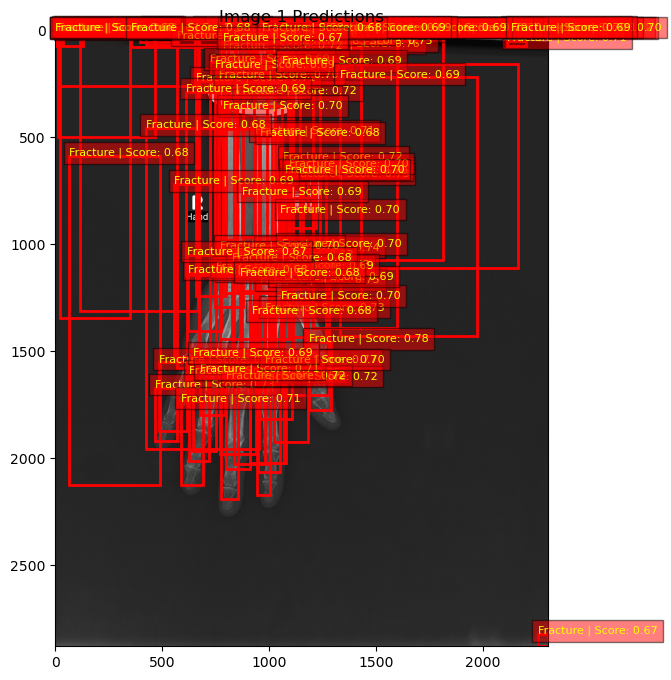

Saved: prediction_outputs\prediction_1.jpg


<Figure size 640x480 with 0 Axes>

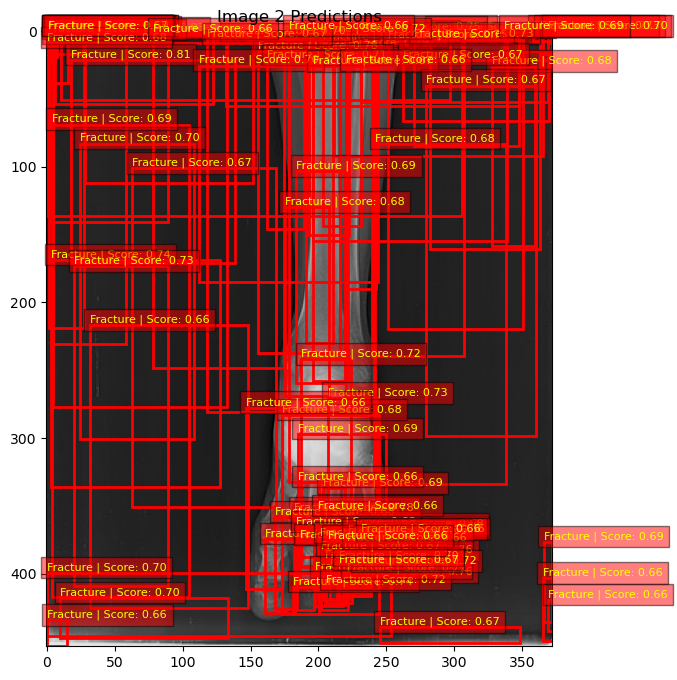

Saved: prediction_outputs\prediction_2.jpg


<Figure size 640x480 with 0 Axes>

In [39]:
# Put the model in eval mode for inference.
model.eval()

# Disable gradients
with torch.no_grad():
    # Get predictions
    predictions = model(images)

# Adjust threshold to retain low-confidence detections
filtered_preds = []
for pred in predictions:
    if "scores" in pred and pred["scores"].numel() > 0:  # Ensure scores exist
        keep_indices = pred["scores"] > 0.5  # Directly filter scores tensor
        filtered_pred = {k: v[keep_indices] if k in ["boxes", "labels", "scores"] else v for k, v in pred.items()}
    else:
        filtered_pred = pred  # Keep empty predictions unchanged
    filtered_preds.append(filtered_pred)

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define function for visualizing the predictions.
def visualize_predictions(images, predictions):
    for i, (image, pred) in enumerate(zip(images, predictions)):
        image = image.permute(1, 2, 0).cpu().numpy()  # Convert tensor to NumPy array

        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(image)

        # Draw bounding boxes
        for box, score, label in zip(pred["boxes"], pred["scores"], pred["labels"]):
            box = box.cpu().numpy()
            label_text = label_map.get(label.item(), f"Class {label.item()}")  # Replace label 1 with "Fracture"
            
            rect = patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(box[0], box[1] - 2, f"{label_text} | Score: {score.item():.2f}",
                    color="yellow", fontsize=8, bbox=dict(facecolor="red", alpha=0.5))


        ax.set_title(f"Image {i+1} Predictions")
        plt.show()
        
        # Save figure
        save_dir="prediction_outputs"
        os.makedirs(save_dir, exist_ok=True)  # Ensure save directory exists

        save_path = os.path.join(save_dir, f"prediction_{i+1}.jpg")
        plt.savefig(save_path, bbox_inches="tight")
        plt.close(fig)  # Close plot to save memory

        print(f"Saved: {save_path}")

# Run visualization
visualize_predictions(images, filtered_preds)

## Create function for calculating IoU before training begins.

In [61]:
# Calculate IoU
def calculate_iou(box1, box2):
    # Box format: (x_min, y_min, x_max, y_max)
    x_min_inter = max(box1[0], box2[0])
    y_min_inter = max(box1[1], box2[1])
    x_max_inter = min(box1[2], box2[2])
    y_max_inter = min(box1[3], box2[3])

    # Compute intersection area
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    intersection = inter_width * inter_height

    # Compute individual areas
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection

    # Compute IoU
    return intersection / union if union > 0 else 0

def calculate_metrics(predictions, targets, iou_threshold=0.5):
    """
    Calculate precision, recall, and F1 score for object detection predictions.
    
    Args:
        predictions: List of dictionaries with 'boxes', 'scores', 'labels'
        targets: List of dictionaries with 'boxes', 'labels'
        iou_threshold: IoU threshold to determine true positives
    
    Returns:
        precision, recall, f1_score
    """
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        pred_scores = pred['scores']
        pred_labels = pred['labels']
        
        gt_boxes = target['boxes']
        gt_labels = target['labels']
        
        # Track which ground truth boxes have been matched
        matched_gt = [False] * len(gt_boxes)
        
        # Sort predictions by confidence score (highest first)
        sorted_indices = torch.argsort(pred_scores, descending=True)
        
        for idx in sorted_indices:
            pred_box = pred_boxes[idx]
            pred_label = pred_labels[idx]
            
            best_iou = 0
            best_gt_idx = -1
            
            # Find the best matching ground truth box
            for gt_idx, gt_box in enumerate(gt_boxes):
                if matched_gt[gt_idx] or gt_labels[gt_idx] != pred_label:
                    continue
                
                # Calculate IoU
                iou = box_iou(pred_box.unsqueeze(0), gt_box.unsqueeze(0)).item()
                
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            # Check if we found a match above the threshold
            if best_gt_idx >= 0 and best_iou >= iou_threshold:
                total_tp += 1
                matched_gt[best_gt_idx] = True
            else:
                total_fp += 1
        
        # Count false negatives (unmatched ground truth boxes)
        total_fn += sum(1 for matched in matched_gt if not matched)
    
    # Calculate metrics
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1_score

## Training the model

Begin iterating through the training data and training the model.

After each training epoch, run validation.

Calculating the loss will require remaining in `train` mode.

Calculating other metrics will require `eval` mode.

Save data for creating graphs later.

In [65]:

from torchvision.ops import box_iou

# Set number of epoch
num_epochs = 20

# Initialize variables
precision_scores = []
recall_scores = []
f1_scores = []
train_losses = []
val_losses = []
iou_scores = []
map_scores_50 = []
map_scores_75 = []
iou_metric = IntersectionOverUnion()

# Begin training
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]  # Move images to GPU/CPU
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]  # Ensure all target tensors match device

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        # Backpropagation
        loss.backward()
        optimizer.step()
        
        # Accumulate loss
        total_train_loss += loss.item()
        
        # Update progress bar description to show loss
        progress_bar.set_postfix(loss=f"{total_train_loss:.4f}")

    train_losses.append(total_train_loss / len(train_loader))  # Store average train loss
    
    # Validation Step (No Gradients)
    # Initialize metrics
    map_metric = MeanAveragePrecision(iou_thresholds=[0.5, 0.75], rec_thresholds=torch.linspace(0, 1, 11).tolist())
    
    # Train mode for Loss Computation**
    model.train()
    total_val_loss = 0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
    
            # Compute validation loss
            loss_dict = model(images, targets)
            total_val_loss += sum(loss_dict.values()).item()
    
        val_losses.append(total_val_loss / len(val_loader) if len(val_loader) > 0 else 0)
    
    # Eval mode for IoU, mAP computation
    model.eval()
    map_metric.reset()

    total_precision = 0
    total_recall = 0
    total_f1 = 0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
    
            predictions = model(images)
    
            formatted_preds = [{'boxes': pred['boxes'].cpu(), 'scores': pred['scores'].cpu(), 'labels': pred['labels'].cpu()} for pred in predictions]
            formatted_gt = [{'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()} for target in targets]
    
            # Update mAP metric
            map_metric.update(formatted_preds, formatted_gt)
            
            # Compute IoU and store results
            iou_metric.update(formatted_preds, formatted_gt)
                    
            # Calculate precision, recall, F1
            precision, recall, f1 = calculate_metrics(formatted_preds, formatted_gt)
            
            # Accumulate metrics
            total_precision += precision
            total_recall += recall
            total_f1 += f1

    # Average the metrics
    avg_precision = total_precision / len(val_loader)
    avg_recall = total_recall / len(val_loader)
    avg_f1 = total_f1 / len(val_loader)
    
    # Print and store results
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1 Score: {avg_f1:.4f}")
    
    precision_scores.append(avg_precision)
    recall_scores.append(avg_recall)
    f1_scores.append(avg_f1)
    
    # Compute final metrics for the epoch
    iou_results = iou_metric.compute()
    mean_iou = iou_results["iou"].mean().item()
    iou_scores.append(mean_iou)

    map_results = map_metric.compute()
    map_scores_50.append(map_results["map_50"])
    map_scores_75.append(map_results["map_75"])

    # Print epoch results
    print(f"Train Loss: {total_train_loss / len(train_loader)}")
    print(f"Validation Loss: {total_val_loss / len(val_loader) : .4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"mAP@0.5: {map_results['map_50']:.4f}, mAP@0.75: {map_results['map_75']:.4f}")

    # Save model every 5 epochs.
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pth")

print("Training complete!")

Precision: 0.2540
Recall: 0.5968
F1 Score: 0.3281
Train Loss: 0.13842927869604024
Validation Loss:  0.2692
Mean IoU: 0.1694
mAP@0.5: 0.4369, mAP@0.75: 0.0943


Precision: 0.1957
Recall: 0.6798
F1 Score: 0.2880
Train Loss: 0.12007479413772709
Validation Loss:  0.2429
Mean IoU: 0.1634
mAP@0.5: 0.5352, mAP@0.75: 0.1728


Precision: 0.3907
Recall: 0.5593
F1 Score: 0.4228
Train Loss: 0.10661426068442624
Validation Loss:  0.2686
Mean IoU: 0.1700
mAP@0.5: 0.4364, mAP@0.75: 0.0917


Precision: 0.3806
Recall: 0.6282
F1 Score: 0.4394
Train Loss: 0.09445289635336357
Validation Loss:  0.2766
Mean IoU: 0.1773
mAP@0.5: 0.4787, mAP@0.75: 0.1345


Precision: 0.3902
Recall: 0.6579
F1 Score: 0.4585
Train Loss: 0.0867617865537621
Validation Loss:  0.2749
Mean IoU: 0.1858
mAP@0.5: 0.5364, mAP@0.75: 0.1329


...

Precision: 0.5255
Recall: 0.5677
F1 Score: 0.5201
Train Loss: 0.05424936544085213
Validation Loss:  0.3688
Mean IoU: 0.2145
mAP@0.5: 0.4915, mAP@0.75: 0.1270


Precision: 0.5130
Recall: 0.5407
F1 Score: 0.5095
Train Loss: 0.050762681086070655
Validation Loss:  0.3665
Mean IoU: 0.2167
mAP@0.5: 0.5055, mAP@0.75: 0.1248


Precision: 0.4935
Recall: 0.4852
F1 Score: 0.4631
Train Loss: 0.052103930039376745
Validation Loss:  0.4328
Mean IoU: 0.2182
mAP@0.5: 0.4064, mAP@0.75: 0.1159


Precision: 0.5404
Recall: 0.5722
F1 Score: 0.5202
Train Loss: 0.05203754315315016
Validation Loss:  0.3984
Mean IoU: 0.2201
mAP@0.5: 0.5086, mAP@0.75: 0.1149


Precision: 0.6083
Recall: 0.4875
F1 Score: 0.5169
Train Loss: 0.05177441685872626
Validation Loss:  0.4041
Mean IoU: 0.2217
mAP@0.5: 0.4005, mAP@0.75: 0.1294
Training complete!


## Graphing the Results.

Training Vs. Validation Loss Curve.

IoU Score

mAP Score @ 0.5 and 0.75

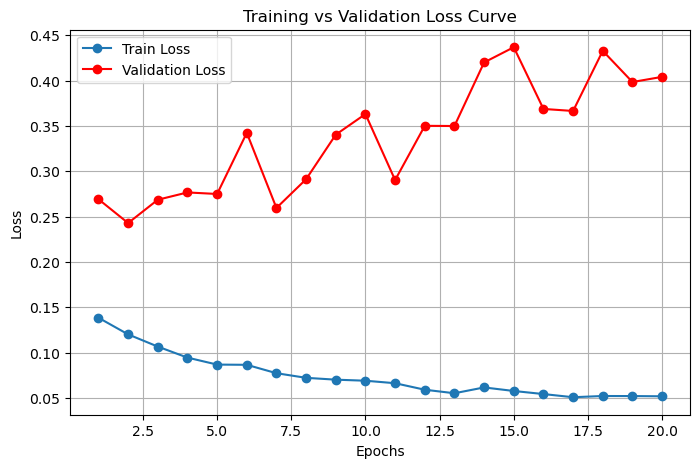

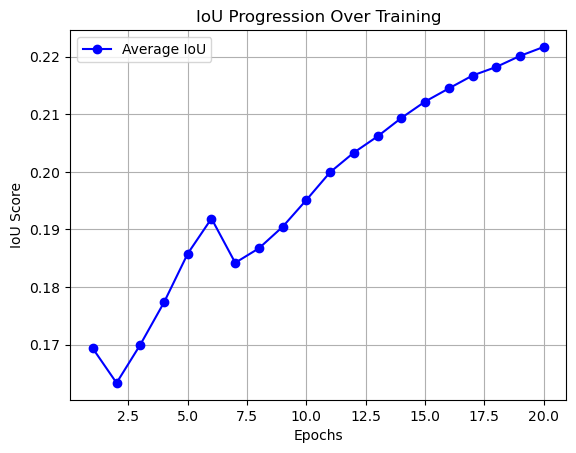

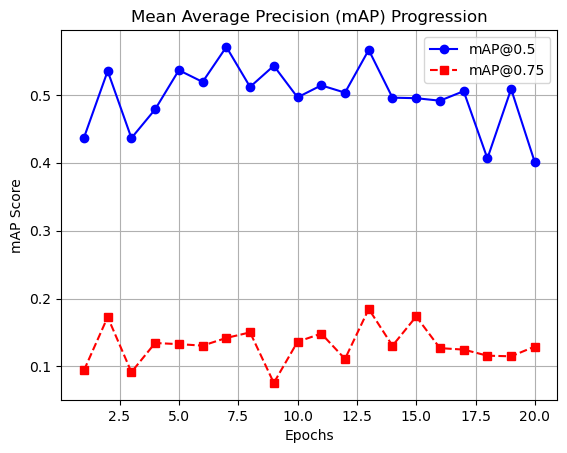

In [67]:
# Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()
plt.show()

# IoU Score
epochs = range(1, len(iou_scores) + 1)
plt.plot(epochs, iou_scores, marker='o', linestyle='-', color='b', label="Average IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU Score")
plt.title("IoU Progression Over Training")
plt.legend()
plt.grid(True)
plt.show()

# mAP Score
epochs = range(1, len(map_scores_50) + 1)
plt.plot(epochs, map_scores_50, marker="o", linestyle="-", color="b", label="mAP@0.5")
plt.plot(epochs, map_scores_75, marker="s", linestyle="--", color="r", label="mAP@0.75")
plt.xlabel("Epochs")
plt.ylabel("mAP Score")
plt.title("Mean Average Precision (mAP) Progression")
plt.legend()
plt.grid(True)
plt.show()

## Post-training prediction

Let's ensure that the model can now make a meaningful prediction on an image directly from the dataset.

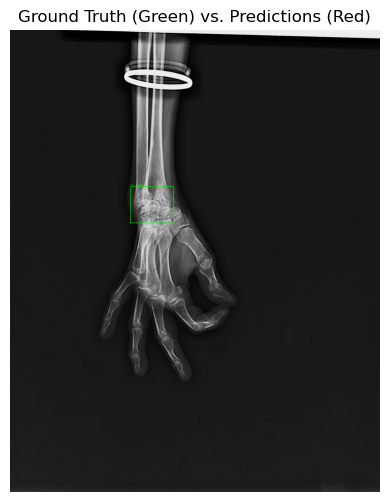

✅ Output saved: predictions_vs_ground_truth\comparison_image.jpg


In [69]:
# Select a sample image from the validation set
sample_image, sample_target = modified_dataset[18]  # Replace with relevant index

# Move image to CPU for visualization
image_np = sample_image.permute(1, 2, 0).cpu().numpy()  # Convert [C, H, W] → [H, W, C]
image_np = (image_np * 255).astype(np.uint8)  # Scale pixel values
image_np = np.ascontiguousarray(image_np)

# Get ground truth boxes & labels
gt_boxes = sample_target["boxes"].cpu().tolist()
gt_labels = sample_target["labels"].cpu().tolist()

# Run inference using trained model
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    predictions = model([sample_image.to(device)])[0]  # Single image inference

# Get predicted boxes & labels
pred_boxes = predictions["boxes"].cpu().tolist()
pred_labels = predictions["labels"].cpu().tolist()

# Draw Ground Truth Boxes (Green)
for box, label in zip(gt_boxes, gt_labels):
    x1, y1, x2, y2 = map(int, box)
    label_text = label_map.get(label, "Unknown")  # Map label to name

    cv2.rectangle(image_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image_np, f"GT: {label_text}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Draw Predicted Boxes (Red)
for box, label in zip(pred_boxes, pred_labels):
    x1, y1, x2, y2 = map(int, box)
    label_text = label_map.get(label, "Unknown")  # Map predictions as well

    cv2.rectangle(image_np, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(image_np, f"Pred: {label_text}", (x1, y1 - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

# Display the comparison
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Ground Truth (Green) vs. Predictions (Red)")
plt.show()

# Define output directory
output_folder = "predictions_vs_ground_truth"
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist

# Generate output file path
output_path = os.path.join(output_folder, "comparison_image.jpg")

# Save annotated image
cv2.imwrite(output_path, cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))

print(f"✅ Output saved: {output_path}")

## Run test on entire test dataset

Visualize predictions against ground truth on test data.

Save output.

In [71]:
# Adjust as needed
confidence_threshold = 0.5

# Iterate through all batches in validation loader
for batch_idx, (images, targets) in enumerate(test_loader):
    images = [img.to(device) for img in images]  # Move images to device
    targets = [{k: v.to(device) for k, v in target.items()} for target in targets]  # Move targets

    for i, (image, target) in enumerate(zip(images, targets)):
        image_np = image.permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * 255).astype(np.uint8)  # Normalize pixels
        image_np = np.ascontiguousarray(image_np)  # Ensure proper memory layout

        # Get ground truth boxes & labels
        gt_boxes = target["boxes"].cpu().tolist()
        gt_labels = target["labels"].cpu().tolist()

        # Run inference
        model.eval()
        with torch.no_grad():
            predictions = model([image])[0]

        # **Filter predictions based on confidence threshold**
        filtered_indices = predictions["scores"] > confidence_threshold
        pred_boxes = predictions["boxes"][filtered_indices].cpu().tolist()
        pred_labels = predictions["labels"][filtered_indices].cpu().tolist()
        pred_scores = predictions["scores"][filtered_indices].cpu().tolist()

        # Draw ground truth (Green)
        for box, label in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = map(int, box)
            label_text = label_map.get(label, "Unknown")
            cv2.rectangle(image_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image_np, f"GT: {label_text}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        # Draw **filtered** predictions (Red)
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            x1, y1, x2, y2 = map(int, box)
            label_text = f"{label_map.get(label, 'Unknown')} ({score:.2f})"
            cv2.rectangle(image_np, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image_np, label_text, (x1, y1 - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        # Save each image
        output_path = f"predictions_vs_ground_truth/image_batch{batch_idx}_sample{i}.jpg"
        cv2.imwrite(output_path, cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))
        #print(f"✅ Saved: {output_path}")

print("Saved all images to predictions_vs_ground_truth/")

Saved all images to predictions_vs_ground_truth/
